# 📊 DRM Project — Derivative Risk Management Analysis

**Stocks:** JSWSTEEL.NS (Large Cap) | RATEGAIN.NS (Small Cap)  
**Period:** 2025-03-04 → 2026-03-04  

---

### Pipeline
1. Data Extraction & Log Returns  
2. Descriptive Statistics  
3. Price & Return Visuals  
4. Distribution Analysis  
5. Rolling Volatility  
6. Correlation Analysis  
7. Dividend Check

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Dark theme for all charts
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})

print("✅ Libraries loaded.")

✅ Libraries loaded.


## 1️⃣ Data Extraction & Log Returns

In [7]:
# Load pre-extracted data (skip yfinance metadata rows)
data = pd.read_excel("DRM_Project_Base_Data.xlsx", skiprows=[1, 2])
data.rename(columns={'Price': 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Ensure numeric
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.dropna(inplace=True)

print(f"📅 Date range: {data.index.min().date()} → {data.index.max().date()}")
print(f"📈 Total trading days: {len(data)}")
print()
data.head(10)

📅 Date range: 2025-03-05 → 2026-02-27
📈 Total trading days: 244



,JSWSTEEL_Close,RATEGAIN_Close,JSW_Log_Return,RATE_Log_Return
Date,,,,
2025-03-05,1000.007141,496.750000,0.028938,0.015622
2025-03-06,1008.384583,505.350006,0.008342,0.017164
2025-03-07,1008.434448,506.350006,0.000049,0.001977
2025-03-10,1010.778137,489.100006,0.002321,-0.034661
2025-03-11,1015.914307,479.250000,0.005069,-0.020345
2025-03-12,1007.686462,466.899994,-0.008132,-0.026107
2025-03-13,998.511169,450.000000,-0.009147,-0.036868
2025-03-17,1002.999084,433.950012,0.004485,-0.036318
2025-03-18,1002.999084,433.950012,0.000000,0.000000


## 2️⃣ Descriptive Statistics

In [9]:
def compute_stats(series, name):
    return {
        'Stock': name,
        'Mean Daily Return': f"{series.mean():.6f}",
        'Annualized Return': f"{series.mean() * 252:.4f} ({series.mean() * 252 * 100:.2f}%)",
        'Daily Volatility': f"{series.std():.6f}",
        'Annualized Volatility': f"{series.std() * np.sqrt(252):.4f} ({series.std() * np.sqrt(252) * 100:.2f}%)",
        'Skewness': f"{skew(series):.4f}",
        'Excess Kurtosis': f"{kurtosis(series):.4f}",
    }

jsw_stats = compute_stats(data['JSW_Log_Return'], 'JSWSTEEL')
rate_stats = compute_stats(data['RATE_Log_Return'], 'RATEGAIN')

stats_df = pd.DataFrame([jsw_stats, rate_stats]).set_index('Stock')
print("📊 Descriptive Statistics — Log Returns\n")
stats_df

📊 Descriptive Statistics — Log Returns



,Mean Daily Return,Annualized Return,Daily Volatility,Annualized Volatility,Skewness,Excess Kurtosis
Stock,,,,,,
JSWSTEEL,0.001081,0.2724 (27.24%),0.015373,0.2440 (24.40%),-0.2633,4.2981
RATEGAIN,0.000325,0.0818 (8.18%),0.024446,0.3881 (38.81%),0.2145,1.6808


## 3️⃣ Closing Price — Time Series

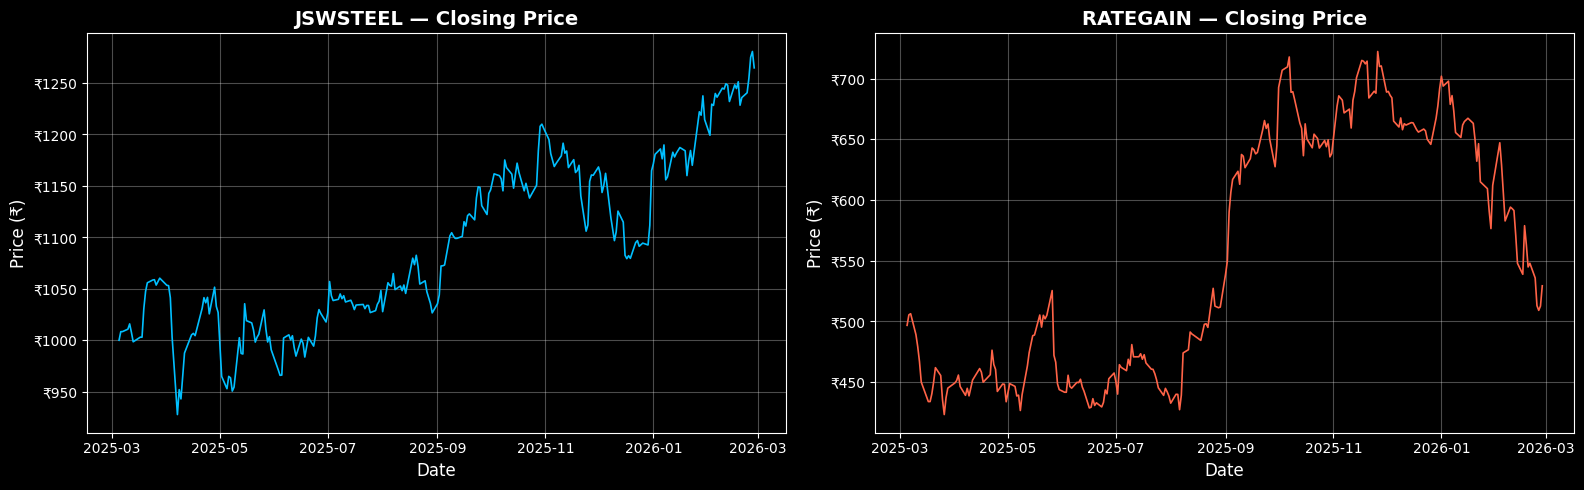

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# JSWSTEEL Price
ax1.plot(data.index, data['JSWSTEEL_Close'], color='#00BFFF', linewidth=1.2)
ax1.set_title('JSWSTEEL — Closing Price', fontweight='bold')
ax1.set_ylabel('Price (₹)')
ax1.set_xlabel('Date')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0f'))

# RATEGAIN Price
ax2.plot(data.index, data['RATEGAIN_Close'], color='#FF6347', linewidth=1.2)
ax2.set_title('RATEGAIN — Closing Price', fontweight='bold')
ax2.set_ylabel('Price (₹)')
ax2.set_xlabel('Date')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0f'))

plt.tight_layout()
plt.show()

## 4️⃣ Daily Log Returns — Time Series

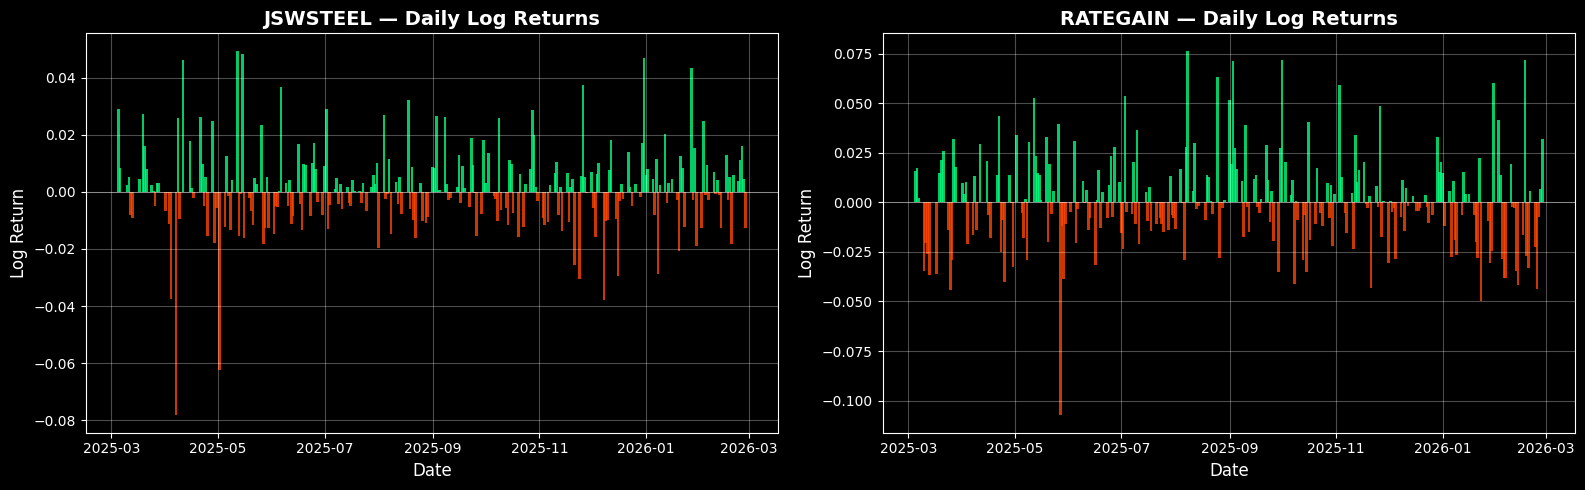

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# JSWSTEEL Returns
ax1.bar(data.index, data['JSW_Log_Return'], color=np.where(data['JSW_Log_Return'] >= 0, '#00FF7F', '#FF4500'), width=1.5, alpha=0.8)
ax1.axhline(0, color='white', linewidth=0.5, alpha=0.5)
ax1.set_title('JSWSTEEL — Daily Log Returns', fontweight='bold')
ax1.set_ylabel('Log Return')
ax1.set_xlabel('Date')

# RATEGAIN Returns
ax2.bar(data.index, data['RATE_Log_Return'], color=np.where(data['RATE_Log_Return'] >= 0, '#00FF7F', '#FF4500'), width=1.5, alpha=0.8)
ax2.axhline(0, color='white', linewidth=0.5, alpha=0.5)
ax2.set_title('RATEGAIN — Daily Log Returns', fontweight='bold')
ax2.set_ylabel('Log Return')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

## 5️⃣ Return Distribution — Histograms

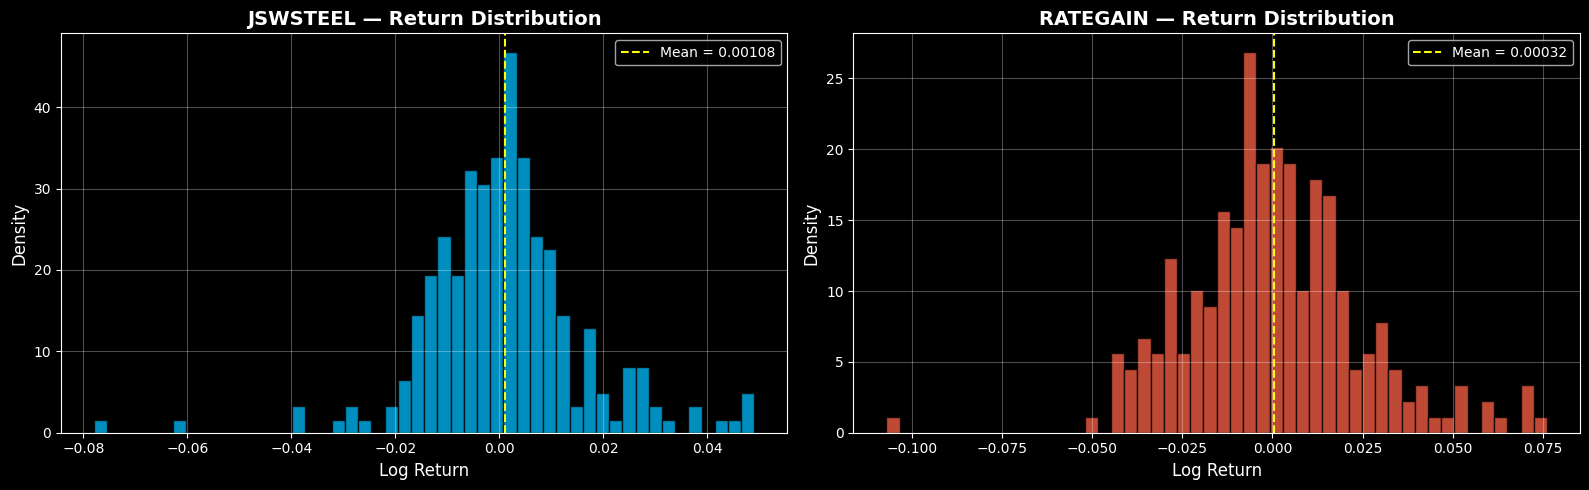

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# JSWSTEEL Distribution
ax1.hist(data['JSW_Log_Return'], bins=50, color='#00BFFF', edgecolor='black', alpha=0.75, density=True)
ax1.axvline(data['JSW_Log_Return'].mean(), color='yellow', linestyle='--', linewidth=1.5, label=f"Mean = {data['JSW_Log_Return'].mean():.5f}")
ax1.set_title('JSWSTEEL — Return Distribution', fontweight='bold')
ax1.set_xlabel('Log Return')
ax1.set_ylabel('Density')
ax1.legend()

# RATEGAIN Distribution
ax2.hist(data['RATE_Log_Return'], bins=50, color='#FF6347', edgecolor='black', alpha=0.75, density=True)
ax2.axvline(data['RATE_Log_Return'].mean(), color='yellow', linestyle='--', linewidth=1.5, label=f"Mean = {data['RATE_Log_Return'].mean():.5f}")
ax2.set_title('RATEGAIN — Return Distribution', fontweight='bold')
ax2.set_xlabel('Log Return')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

## 6️⃣ Rolling 30-Day Volatility

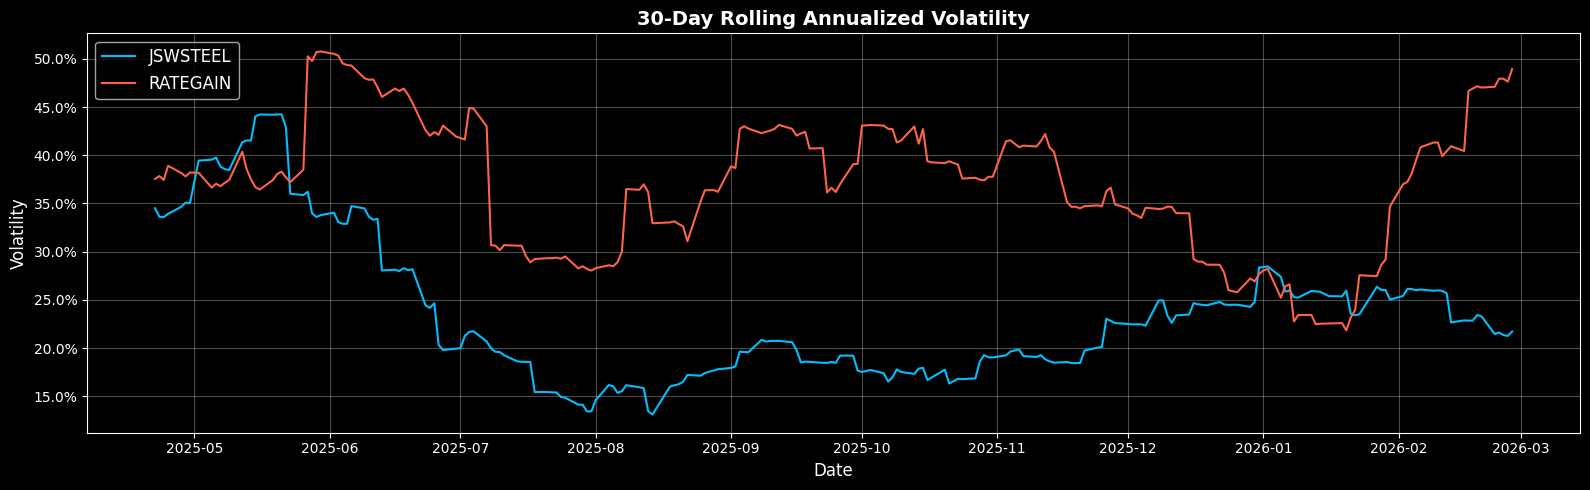

In [13]:
# Rolling 30-day annualized volatility
window = 30
data['JSW_Rolling_Vol'] = data['JSW_Log_Return'].rolling(window).std() * np.sqrt(252)
data['RATE_Rolling_Vol'] = data['RATE_Log_Return'].rolling(window).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(data.index, data['JSW_Rolling_Vol'], color='#00BFFF', linewidth=1.5, label='JSWSTEEL')
ax.plot(data.index, data['RATE_Rolling_Vol'], color='#FF6347', linewidth=1.5, label='RATEGAIN')
ax.set_title('30-Day Rolling Annualized Volatility', fontweight='bold')
ax.set_ylabel('Volatility')
ax.set_xlabel('Date')
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 7️⃣ Correlation Analysis

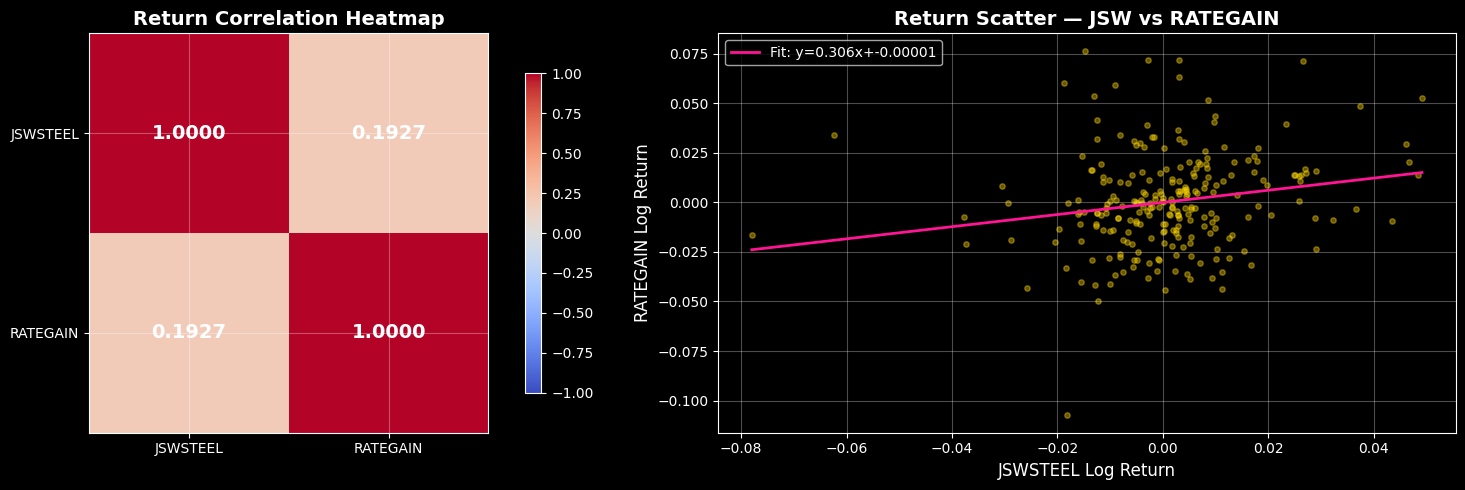


📊 Pearson Correlation: 0.1927


In [14]:
# Correlation between log returns
corr_matrix = data[['JSW_Log_Return', 'RATE_Log_Return']].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
im = ax1.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['JSWSTEEL', 'RATEGAIN'])
ax1.set_yticklabels(['JSWSTEEL', 'RATEGAIN'])
ax1.set_title('Return Correlation Heatmap', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{corr_matrix.iloc[i, j]:.4f}", ha='center', va='center', fontsize=14, fontweight='bold', color='white')
fig.colorbar(im, ax=ax1, shrink=0.8)

# Scatter plot
ax2.scatter(data['JSW_Log_Return'], data['RATE_Log_Return'], alpha=0.4, s=15, color='#FFD700')
z = np.polyfit(data['JSW_Log_Return'], data['RATE_Log_Return'], 1)
p = np.poly1d(z)
x_line = np.linspace(data['JSW_Log_Return'].min(), data['JSW_Log_Return'].max(), 100)
ax2.plot(x_line, p(x_line), color='#FF1493', linewidth=2, label=f'Fit: y={z[0]:.3f}x+{z[1]:.5f}')
ax2.set_title('Return Scatter — JSW vs RATEGAIN', fontweight='bold')
ax2.set_xlabel('JSWSTEEL Log Return')
ax2.set_ylabel('RATEGAIN Log Return')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Pearson Correlation: {corr_matrix.iloc[0,1]:.4f}")

## 8️⃣ Dividend Check — JSWSTEEL

In [15]:
ticker = yf.Ticker("JSWSTEEL.NS")
dividends = ticker.dividends

period_divs = dividends["2025-03-04":"2026-03-04"]

if len(period_divs) > 0:
    print("✅ JSWSTEEL declared dividends in this period:\n")
    for date, amount in period_divs.items():
        print(f"   📅 {date.strftime('%Y-%m-%d')}  →  ₹{amount:.2f} per share")
    print(f"\n   💰 Total Dividend: ₹{period_divs.sum():.2f} per share")
else:
    print("❌ No dividends declared by JSWSTEEL in this period.")

✅ JSWSTEEL declared dividends in this period:

   📅 2025-07-08  →  ₹2.80 per share

   💰 Total Dividend: ₹2.80 per share


## 9️⃣ Normalized Price Comparison (Base = 100)

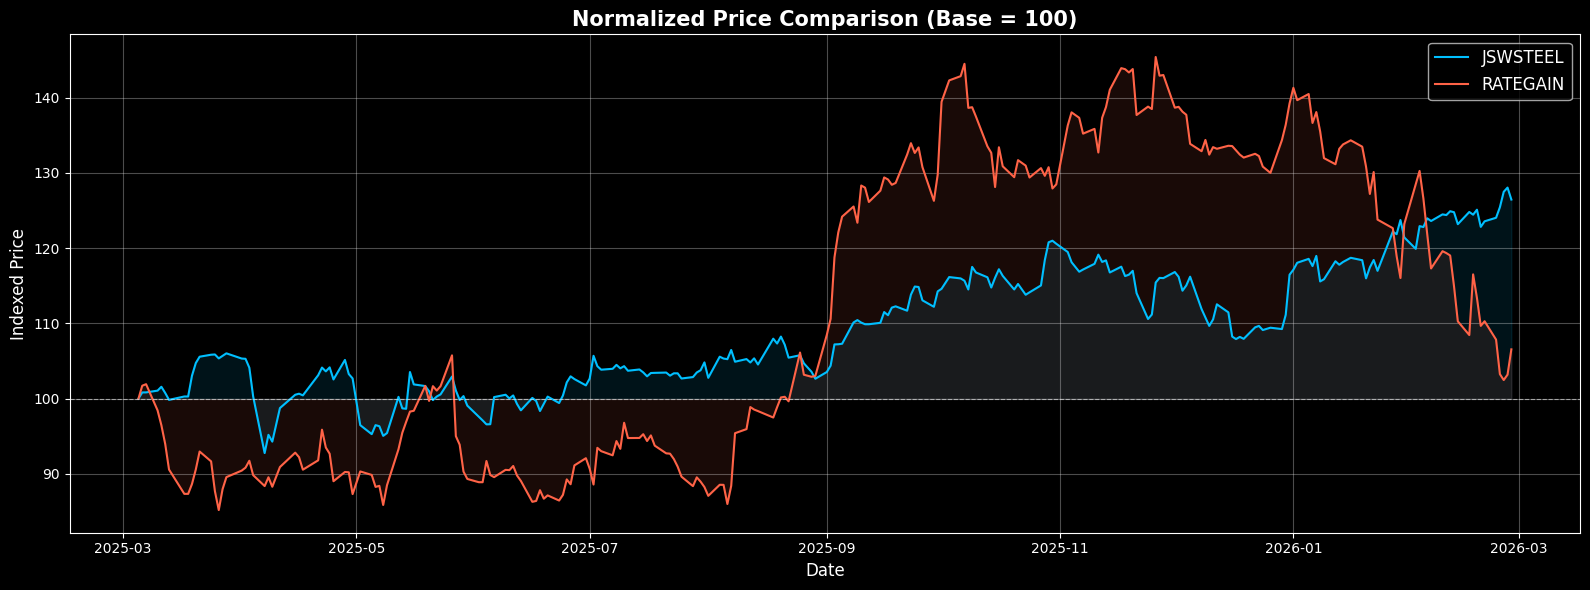

In [16]:
# Normalize to base 100 for comparison
jsw_norm = (data['JSWSTEEL_Close'] / data['JSWSTEEL_Close'].iloc[0]) * 100
rate_norm = (data['RATEGAIN_Close'] / data['RATEGAIN_Close'].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(data.index, jsw_norm, color='#00BFFF', linewidth=1.5, label='JSWSTEEL')
ax.plot(data.index, rate_norm, color='#FF6347', linewidth=1.5, label='RATEGAIN')
ax.axhline(100, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.fill_between(data.index, jsw_norm, 100, alpha=0.1, color='#00BFFF')
ax.fill_between(data.index, rate_norm, 100, alpha=0.1, color='#FF6347')
ax.set_title('Normalized Price Comparison (Base = 100)', fontweight='bold', fontsize=15)
ax.set_ylabel('Indexed Price')
ax.set_xlabel('Date')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()